In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Import Data

In [7]:
df_use = pd.read_csv("C:/Users/dlmat/Documents/Projects/Differencial_Bio/data/EDA_OD600/norm_df_final.csv")

In [8]:
df_trust = df_use[df_use['final_class']!= 'rerun']

# Model historically trained that predicts OD

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error


In [10]:
features = [
    "K2HPO4: Dipotassium phosphate",
    "Peptone (Soy)",
    "Glucose",
    "Ammonium citrate",
    "MgSO4: Magnesium sulfate",
    "Yeast extract",
    "MnSO4 · H2O: Manganese sulfate",
    "Meat extract",
    "CH3COONa: Sodium acetate",
    "Tween 80 [ml/L]"
]

X = df_trust[features]
y = df_trust["median_od_norm"]


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

In [13]:
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=5, n_estimators=500,
                      n_jobs=-1, random_state=42)

## Eval Metrics

In [14]:
y_pred = rf.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R²: 0.6917199023884787
MAE: 0.14953597048556802


In [15]:
cv_scores = cross_val_score(rf, X, y, cv=5, scoring="r2")
print("CV R² mean:", cv_scores.mean())

CV R² mean: 0.6086236018574038


## Feature Importance

In [16]:
importances = pd.Series(rf.feature_importances_, index=features)
importances = importances.sort_values(ascending=False)

print(importances)


Glucose                           0.592814
MnSO4 · H2O: Manganese sulfate    0.123226
Ammonium citrate                  0.081808
Yeast extract                     0.066506
Meat extract                      0.044977
Tween 80 [ml/L]                   0.022642
K2HPO4: Dipotassium phosphate     0.018815
CH3COONa: Sodium acetate          0.018420
MgSO4: Magnesium sulfate          0.015858
Peptone (Soy)                     0.014934
dtype: float64


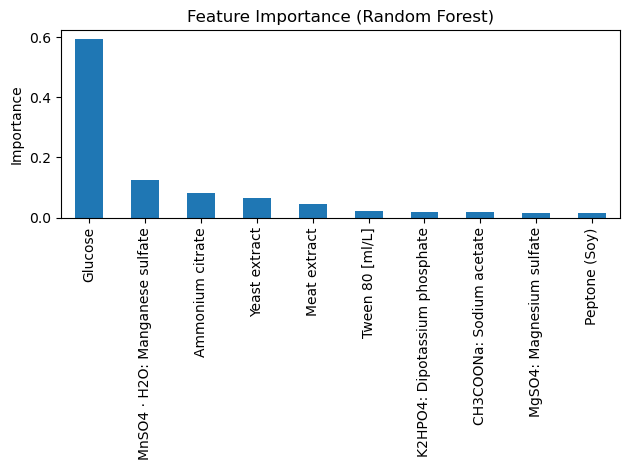

In [19]:
import matplotlib.pyplot as plt

importances.plot(kind="bar",)
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


# Creating 400 exploratory combiantions. 

In [20]:
# obtained from fermentaion data. 
levels_dict = {
    'K2HPO4: Dipotassium phosphate': np.array([1, 2, 4]),
    'Peptone (Soy)': np.array([10, 5, 0, 40, 20]),
    'Glucose': np.array([10, 0, 50, 40, 20]),
    'Ammonium citrate': np.array([2, 1, 0, 4, 10]),
    'MgSO4: Magnesium sulfate': np.array([0.1, 0.2, 0., 2., 1.]),
    'Yeast extract': np.array([5, 20, 10, 40, 0]),
    'MnSO4 · H2O: Manganese sulfate': np.array([1., 0., 0.1, 0.2, 2.]),
    'Meat extract': np.array([0, 40, 5, 10, 20]),
    'CH3COONa: Sodium acetate': np.array([2.5, 5., 10., 15., 0.]),
    'Tween 80 [ml/L]': np.array([0., 2., 0.5, 4., 1.])
}


In [21]:
from scipy.stats import qmc
import pandas as pd
import numpy as np

n_samples = 400
n_factors = len(levels_dict)

sampler = qmc.LatinHypercube(d=n_factors, seed=42)
lhs_sample = sampler.random(n=n_samples)

lhs_df = pd.DataFrame(lhs_sample, columns=levels_dict.keys())


In [22]:
def map_to_discrete(column, allowed_levels):
    allowed_levels = np.sort(allowed_levels)
    bins = np.linspace(0, 1, len(allowed_levels) + 1)
    indices = np.digitize(column, bins) - 1
    indices = np.clip(indices, 0, len(allowed_levels)-1)
    return allowed_levels[indices]

exploration_df = pd.DataFrame()

for col in lhs_df.columns:
    exploration_df[col] = map_to_discrete(
        lhs_df[col].values,
        levels_dict[col]
    )


In [25]:
for col in exploration_df.columns:
    print(f"\n{col}")
    print(exploration_df[col].value_counts())



K2HPO4: Dipotassium phosphate
K2HPO4: Dipotassium phosphate
4    134
2    133
1    133
Name: count, dtype: int64

Peptone (Soy)
Peptone (Soy)
0     80
10    80
20    80
5     80
40    80
Name: count, dtype: int64

Glucose
Glucose
10    80
0     80
40    80
20    80
50    80
Name: count, dtype: int64

Ammonium citrate
Ammonium citrate
4     80
1     80
2     80
10    80
0     80
Name: count, dtype: int64

MgSO4: Magnesium sulfate
MgSO4: Magnesium sulfate
0.1    80
2.0    80
1.0    80
0.2    80
0.0    80
Name: count, dtype: int64

Yeast extract
Yeast extract
5     80
20    80
0     80
10    80
40    80
Name: count, dtype: int64

MnSO4 · H2O: Manganese sulfate
MnSO4 · H2O: Manganese sulfate
2.0    80
0.1    80
0.0    80
0.2    80
1.0    80
Name: count, dtype: int64

Meat extract
Meat extract
20    80
0     80
40    80
10    80
5     80
Name: count, dtype: int64

CH3COONa: Sodium acetate
CH3COONa: Sodium acetate
2.5     80
0.0     80
5.0     80
15.0    80
10.0    80
Name: count, dtype: in

In [24]:
exploration_df.head()

,K2HPO4: Dipotassium phosphate,Peptone (Soy),Glucose,Ammonium citrate,MgSO4: Magnesium sulfate,Yeast extract,MnSO4 · H2O: Manganese sulfate,Meat extract,CH3COONa: Sodium acetate,Tween 80 [ml/L]
0,2,0,10,4,0.1,5,2.0,20,2.5,2.0
1,4,10,0,4,2.0,20,2.0,0,0.0,0.0
2,2,20,40,1,1.0,0,0.1,20,5.0,2.0
3,2,5,10,2,0.2,20,0.1,20,2.5,0.0
4,4,20,20,4,0.0,10,0.0,40,0.0,0.5


## bar graph composition spread. 

K2HPO4: Dipotassium phosphate 1 33.25
K2HPO4: Dipotassium phosphate 2 33.25
K2HPO4: Dipotassium phosphate 4 33.5
Peptone (Soy) 0 20.0
Peptone (Soy) 5 20.0
Peptone (Soy) 10 20.0
Peptone (Soy) 20 20.0
Peptone (Soy) 40 20.0
Glucose 0 20.0
Glucose 10 20.0
Glucose 20 20.0
Glucose 40 20.0
Glucose 50 20.0
Ammonium citrate 0 20.0
Ammonium citrate 1 20.0
Ammonium citrate 2 20.0
Ammonium citrate 4 20.0
Ammonium citrate 10 20.0
MgSO4: Magnesium sulfate 0.0 20.0
MgSO4: Magnesium sulfate 0.1 20.0
MgSO4: Magnesium sulfate 0.2 20.0
MgSO4: Magnesium sulfate 1.0 20.0
MgSO4: Magnesium sulfate 2.0 20.0
Yeast extract 0 20.0
Yeast extract 5 20.0
Yeast extract 10 20.0
Yeast extract 20 20.0
Yeast extract 40 20.0
MnSO4 · H2O: Manganese sulfate 0.0 20.0
MnSO4 · H2O: Manganese sulfate 0.1 20.0
MnSO4 · H2O: Manganese sulfate 0.2 20.0
MnSO4 · H2O: Manganese sulfate 1.0 20.0
MnSO4 · H2O: Manganese sulfate 2.0 20.0
Meat extract 0 20.0
Meat extract 5 20.0
Meat extract 10 20.0
Meat extract 20 20.0
Meat extract 40 20.

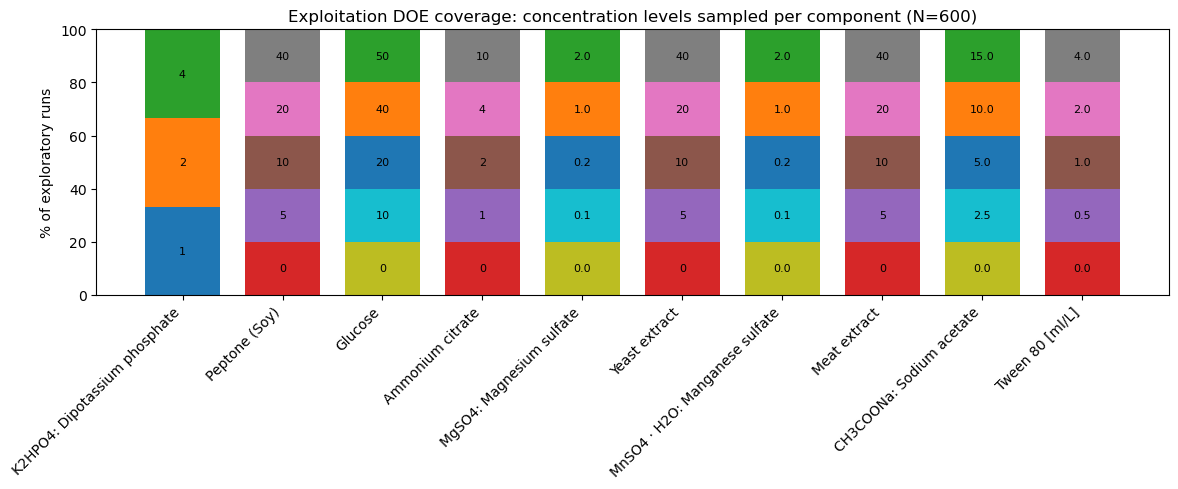

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Your exploratory subset (N=400)
# df_explore = doe_df.query("phase == 'explore'")  # example
# assert len(df_explore) == 400

component_cols = [
    "K2HPO4: Dipotassium phosphate",
    "Peptone (Soy)",
    "Glucose",
    "Ammonium citrate",
    "MgSO4: Magnesium sulfate",
    "Yeast extract",
    "MnSO4 · H2O: Manganese sulfate",
    "Meat extract",
    "CH3COONa: Sodium acetate",
    "Tween 80 [ml/L]"
]

def coverage_stacked_bar(df_explore, component_cols, normalize=True):
    n = len(df_explore)

    fig, ax = plt.subplots(figsize=(12, 5))

    x = np.arange(len(component_cols))
    bar_width = 0.75

    for i, comp in enumerate(component_cols):
        # counts per concentration level
        counts = df_explore[comp].value_counts(dropna=False).sort_index()

        # convert to %
        if normalize:
            vals = (counts / n) * 100.0
            ylab = "% of exploratory runs"
        else:
            vals = counts
            ylab = "count"

        bottom = 0.0
        for level, v in vals.items():
            ax.bar(i, v, bottom=bottom, width=bar_width, label=f"{comp}={level}" if False else None)
            print(comp, level, v)
            # annotate segment with level value 
            ax.text(i, bottom + v/2, str(level), ha="center", va="center", fontsize=8)
            bottom += v

    ax.set_xticks(x)
    ax.set_xticklabels(component_cols, rotation=45, ha="right")
    ax.set_ylabel(ylab)
    ax.set_title("Exploitation DOE coverage: concentration levels sampled per component (N=600)")

    # Force 0–100% axis if normalized
    if normalize:
        ax.set_ylim(0, 100)

    plt.tight_layout()
    plt.show()

coverage_stacked_bar(exploration_df, component_cols, normalize=True)

# Predict OD of 400 exploratory combinations

In [30]:
# Ensure same column order as training
X_explore = exploration_df[features].copy()

In [31]:
exploration_df["pred_od"] = rf.predict(X_explore)

In [32]:
exploration_df["pred_od"].describe()

count    400.000000
mean       0.931650
std        0.278387
min        0.309009
25%        0.709715
50%        0.984165
75%        1.168418
max        1.339384
Name: pred_od, dtype: float64

In [33]:
exploration_df.sort_values("pred_od", ascending=False).head(10)

,K2HPO4: Dipotassium phosphate,Peptone (Soy),Glucose,Ammonium citrate,MgSO4: Magnesium sulfate,Yeast extract,MnSO4 · H2O: Manganese sulfate,Meat extract,CH3COONa: Sodium acetate,Tween 80 [ml/L],pred_od
196,4,40,40,4,0.1,40,0.2,40,2.5,1.0,1.339384
49,2,20,40,10,0.1,40,0.2,10,15.0,1.0,1.326034
302,2,40,50,10,2.0,20,0.2,40,2.5,0.0,1.325424
102,2,10,40,4,2.0,20,0.2,20,2.5,0.0,1.325285
334,4,10,20,10,0.2,40,1.0,20,2.5,0.0,1.320164
91,2,5,50,10,1.0,40,0.2,20,5.0,4.0,1.319767
230,4,10,50,10,0.1,10,0.2,10,0.0,2.0,1.318493
139,2,0,20,10,0.0,20,0.1,10,2.5,0.5,1.317291
388,4,10,40,4,0.0,40,0.1,40,10.0,0.0,1.316540
137,4,0,20,4,0.2,40,0.2,40,10.0,0.0,1.316181


In [34]:
# Per-tree predictions -> standard deviation as uncertainty proxy
tree_preds = np.vstack([t.predict(X_explore) for t in rf.estimators_])  # shape: (n_trees, n_samples)

exploration_df["pred_od_std"] = tree_preds.std(axis=0)
exploration_df["pred_od_p10"] = np.percentile(tree_preds, 10, axis=0)
exploration_df["pred_od_p90"] = np.percentile(tree_preds, 90, axis=0)

exploration_df[["pred_od", "pred_od_std", "pred_od_p10", "pred_od_p90"]].describe()


C:\Users\dlmat\miniconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\dlmat\miniconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\dlmat\miniconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\dlmat\miniconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\dlmat\miniconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\dlmat\miniconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but DecisionTreeRegressor 

,pred_od,pred_od_std,pred_od_p10,pred_od_p90
count,400.000000,400.000000,400.000000,400.000000
mean,0.931650,0.146154,0.744598,1.105521
std,0.278387,0.045122,0.308364,0.252907
min,0.309009,0.060668,0.208464,0.419662
25%,0.709715,0.114255,0.478032,0.943823
50%,0.984165,0.139462,0.754159,1.160559
75%,1.168418,0.172950,1.033843,1.322219
max,1.339384,0.307075,1.247667,1.418815


## Prediction histogram

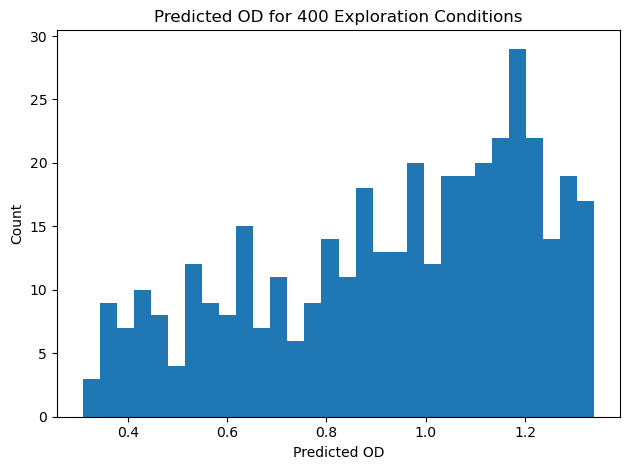

In [35]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(exploration_df["pred_od"], bins=30)
plt.title("Predicted OD for 400 Exploration Conditions")
plt.xlabel("Predicted OD")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## Feature Importance

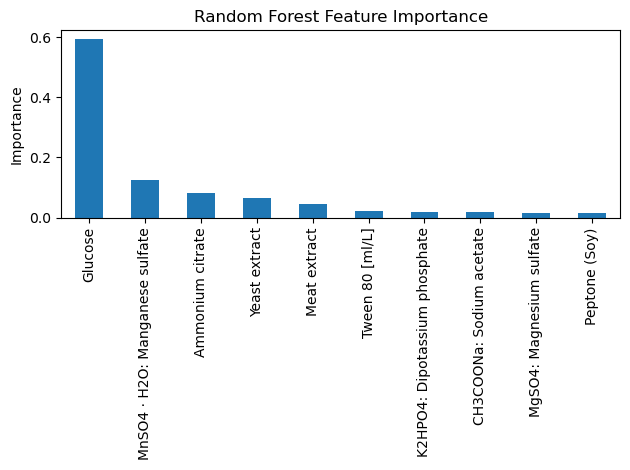

Glucose                           0.592814
MnSO4 · H2O: Manganese sulfate    0.123226
Ammonium citrate                  0.081808
Yeast extract                     0.066506
Meat extract                      0.044977
Tween 80 [ml/L]                   0.022642
K2HPO4: Dipotassium phosphate     0.018815
CH3COONa: Sodium acetate          0.018420
MgSO4: Magnesium sulfate          0.015858
Peptone (Soy)                     0.014934
dtype: float64


In [36]:
import pandas as pd

importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure()
importances.plot(kind="bar")
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

print(importances)


# Model of exploratory and historical data

In [45]:
X2 = pd.concat([X, exploration_df[features]])
y2 = pd.concat([y, exploration_df["pred_od"]])

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

In [49]:
rf2 = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

In [54]:
rf2.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=5, n_estimators=500,
                      n_jobs=-1, random_state=42)

## Eval Model

In [55]:
y_pred = rf2.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R²: 0.6706575760543443
MAE: 0.11067909696991969


In [57]:
cv_scores = cross_val_score(rf2, X2, y2, cv=5, scoring="r2")
print("CV R² mean:", cv_scores.mean())

CV R² mean: 0.8060447788750087


## Feature importance

In [59]:
importances = pd.Series(rf2.feature_importances_, index=features)
importances = importances.sort_values(ascending=False)

print(importances)


Glucose                           0.634473
MnSO4 · H2O: Manganese sulfate    0.131853
Ammonium citrate                  0.091672
Yeast extract                     0.050464
Meat extract                      0.031223
K2HPO4: Dipotassium phosphate     0.018867
Tween 80 [ml/L]                   0.016858
MgSO4: Magnesium sulfate          0.009111
CH3COONa: Sodium acetate          0.008650
Peptone (Soy)                     0.006829
dtype: float64


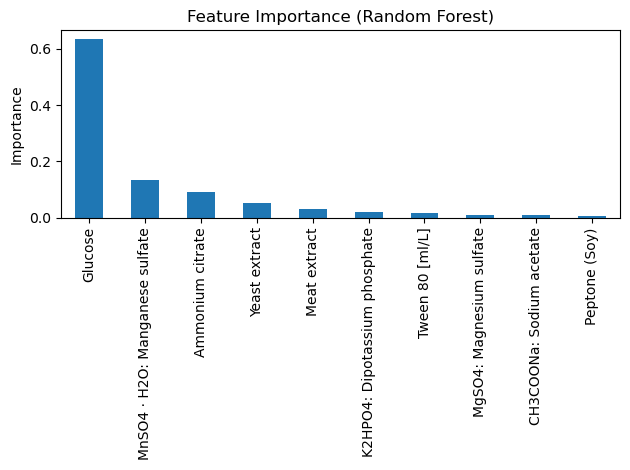

In [60]:
import matplotlib.pyplot as plt

importances.plot(kind="bar",)
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


# Creating the 600 explotation combinations

In [62]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

def sample_candidates(levels_dict, n):
    out = {}
    for col, levels in levels_dict.items():
        levels = np.array(levels)
        out[col] = rng.choice(levels, size=n, replace=True)
    return pd.DataFrame(out)

candidate_pool = sample_candidates(levels_dict, n=50000)  # 50k candidates


## predict 50k od with model

In [63]:
X_cand = candidate_pool[features]
candidate_pool["pred_od"] = rf2.predict(X_cand)

tree_preds = np.vstack([t.predict(X_cand) for t in rf2.estimators_])
candidate_pool["pred_od_std"] = tree_preds.std(axis=0)


C:\Users\dlmat\miniconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\dlmat\miniconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\dlmat\miniconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\dlmat\miniconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\dlmat\miniconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\dlmat\miniconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but DecisionTreeRegressor 

## Select best 5000, then best 600 with diversity-awareness

In [64]:
from sklearn.preprocessing import MinMaxScaler

# Take top 5000 candidates by predicted OD
top = candidate_pool.sort_values("pred_od", ascending=False).head(5000).reset_index(drop=True)

# Scale features to 0-1 for distance computations
scaler = MinMaxScaler()
Z = scaler.fit_transform(top[features].values)

# Greedy max-min diversity selection
n_select = 600
selected_idx = [0]  # start with best predicted

# Track minimum distance to selected set for each point
min_dist = np.full(Z.shape[0], np.inf)

for _ in range(1, n_select):
    last = Z[selected_idx[-1]]
    d = np.linalg.norm(Z - last, axis=1)
    min_dist = np.minimum(min_dist, d)
    next_idx = int(np.argmax(min_dist))
    selected_idx.append(next_idx)

exploitation_df = top.loc[selected_idx, features + ["pred_od", "pred_od_std"]].copy()
exploitation_df["stage"] = "exploit"
exploitation_df = exploitation_df.reset_index(drop=True)

exploitation_df.head()


,K2HPO4: Dipotassium phosphate,Peptone (Soy),Glucose,Ammonium citrate,MgSO4: Magnesium sulfate,Yeast extract,MnSO4 · H2O: Manganese sulfate,Meat extract,CH3COONa: Sodium acetate,Tween 80 [ml/L],pred_od,pred_od_std,stage
0,4,20,50,4,0.2,20,0.2,10,10.0,0.5,1.361226,0.037725,exploit
1,2,20,20,10,2.0,5,2.0,40,15.0,4.0,1.280253,0.064205,exploit
2,2,5,20,4,0.0,40,2.0,0,0.0,4.0,1.272965,0.063563,exploit
3,4,10,20,4,2.0,40,2.0,40,0.0,0.0,1.299579,0.057131,exploit
4,2,40,50,10,2.0,40,2.0,0,2.5,0.0,1.285309,0.064014,exploit


In [65]:
exploitation_df.shape

(600, 13)

## bar graph composition spread.

K2HPO4: Dipotassium phosphate 2 48.66666666666667
K2HPO4: Dipotassium phosphate 4 51.33333333333333
Peptone (Soy) 0 17.666666666666668
Peptone (Soy) 5 14.833333333333334
Peptone (Soy) 10 14.833333333333334
Peptone (Soy) 20 18.333333333333332
Peptone (Soy) 40 34.333333333333336
Glucose 20 42.833333333333336
Glucose 40 25.833333333333336
Glucose 50 31.333333333333336
Ammonium citrate 0 0.5
Ammonium citrate 1 4.833333333333333
Ammonium citrate 2 10.5
Ammonium citrate 4 38.0
Ammonium citrate 10 46.166666666666664
MgSO4: Magnesium sulfate 0.0 19.166666666666668
MgSO4: Magnesium sulfate 0.1 15.0
MgSO4: Magnesium sulfate 0.2 10.833333333333334
MgSO4: Magnesium sulfate 1.0 19.666666666666664
MgSO4: Magnesium sulfate 2.0 35.333333333333336
Yeast extract 5 9.666666666666666
Yeast extract 10 27.166666666666668
Yeast extract 20 22.666666666666664
Yeast extract 40 40.5
MnSO4 · H2O: Manganese sulfate 0.1 25.166666666666664
MnSO4 · H2O: Manganese sulfate 0.2 21.5
MnSO4 · H2O: Manganese sulfate 1.0 21

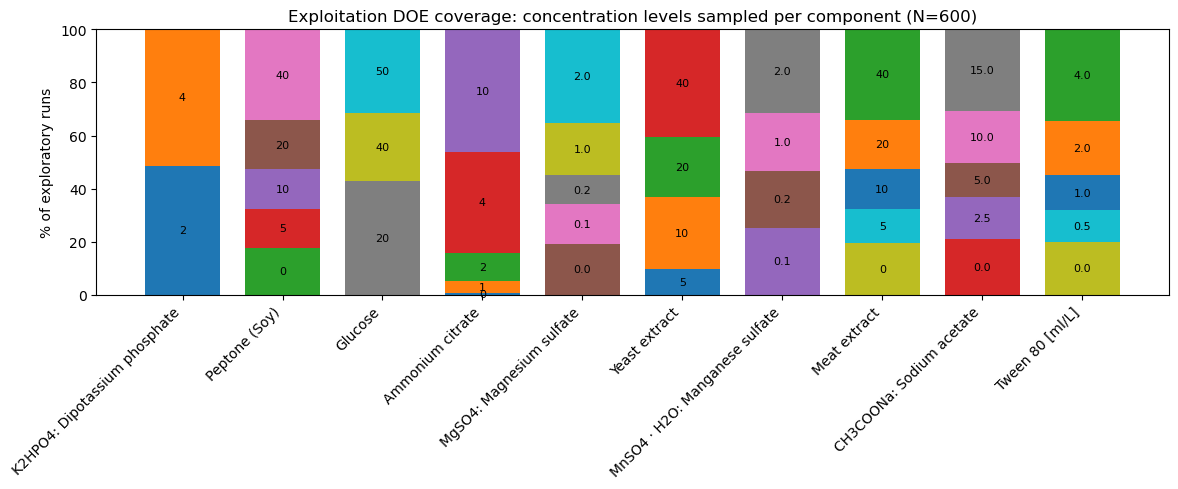

In [76]:
import numpy as np
import matplotlib.pyplot as plt

# Your exploratory subset (N=400)
# df_explore = doe_df.query("phase == 'explore'")  # example
# assert len(df_explore) == 400

component_cols = [
    "K2HPO4: Dipotassium phosphate",
    "Peptone (Soy)",
    "Glucose",
    "Ammonium citrate",
    "MgSO4: Magnesium sulfate",
    "Yeast extract",
    "MnSO4 · H2O: Manganese sulfate",
    "Meat extract",
    "CH3COONa: Sodium acetate",
    "Tween 80 [ml/L]"
]

def coverage_stacked_bar(df_explore, component_cols, normalize=True):
    n = len(df_explore)

    fig, ax = plt.subplots(figsize=(12, 5))

    x = np.arange(len(component_cols))
    bar_width = 0.75

    for i, comp in enumerate(component_cols):
        # counts per concentration level
        counts = df_explore[comp].value_counts(dropna=False).sort_index()

        # convert to %
        if normalize:
            vals = (counts / n) * 100.0
            ylab = "% of exploratory runs"
        else:
            vals = counts
            ylab = "count"

        bottom = 0.0
        for level, v in vals.items():
            ax.bar(i, v, bottom=bottom, width=bar_width, label=f"{comp}={level}" if False else None)
            print(comp, level, v)
            # annotate segment with level value 
            ax.text(i, bottom + v/2, str(level), ha="center", va="center", fontsize=8)
            bottom += v

    ax.set_xticks(x)
    ax.set_xticklabels(component_cols, rotation=45, ha="right")
    ax.set_ylabel(ylab)
    ax.set_title("Exploitation DOE coverage: concentration levels sampled per component (N=600)")

    # Force 0–100% axis if normalized
    if normalize:
        ax.set_ylim(0, 100)

    plt.tight_layout()
    plt.show()

coverage_stacked_bar(exploitation_df, component_cols, normalize=True)

## Final DOE

In [66]:
final_doe = pd.concat(
    [exploration_df.assign(stage="explore"), exploitation_df],
    ignore_index=True
)

print(final_doe.shape)  # should be (1000, ...)
final_doe.head()


(1000, 15)


,K2HPO4: Dipotassium phosphate,Peptone (Soy),Glucose,Ammonium citrate,MgSO4: Magnesium sulfate,Yeast extract,MnSO4 · H2O: Manganese sulfate,Meat extract,CH3COONa: Sodium acetate,Tween 80 [ml/L],pred_od,pred_od_std,pred_od_p10,pred_od_p90,stage
0,2,0,10,4,0.1,5,2.0,20,2.5,2.0,0.816741,0.148276,0.616781,0.991284,explore
1,4,10,0,4,2.0,20,2.0,0,0.0,0.0,0.586476,0.169561,0.372025,0.824626,explore
2,2,20,40,1,1.0,0,0.1,20,5.0,2.0,1.169610,0.119791,1.037311,1.289016,explore
3,2,5,10,2,0.2,20,0.1,20,2.5,0.0,0.991078,0.114920,0.850600,1.130127,explore
4,4,20,20,4,0.0,10,0.0,40,0.0,0.5,1.003512,0.139662,0.811024,1.165276,explore


In [67]:
final_doe.shape

(1000, 15)

In [68]:
final_doe.to_csv("C:/Users/dlmat/Documents/Projects/Differencial_Bio/data/L_rhamnosus_DOE_1000.csv", index=False)


# Top predicted performers from exploitation set 

In [69]:
topN = 30
best = exploitation_df.sort_values("pred_od", ascending=False).head(topN)
best[features + ["pred_od", "pred_od_std"]]


,K2HPO4: Dipotassium phosphate,Peptone (Soy),Glucose,Ammonium citrate,MgSO4: Magnesium sulfate,Yeast extract,MnSO4 · H2O: Manganese sulfate,Meat extract,CH3COONa: Sodium acetate,Tween 80 [ml/L],pred_od,pred_od_std
0,4,20,50,4,0.2,20,0.2,10,10.0,0.5,1.361226,0.037725
182,4,40,40,4,0.2,40,0.1,10,0.0,2.0,1.352729,0.040131
276,2,40,50,4,0.1,20,0.2,40,10.0,0.5,1.350850,0.040348
541,2,40,40,4,0.1,40,0.1,0,10.0,4.0,1.350296,0.038449
27,4,40,40,4,2.0,40,0.1,5,10.0,4.0,1.349624,0.035798
363,4,40,40,4,1.0,20,0.2,40,10.0,0.5,1.348274,0.041001
242,4,40,50,4,0.1,40,0.2,40,2.5,4.0,1.348092,0.036689
562,2,40,50,10,2.0,40,0.1,10,10.0,2.0,1.345602,0.035820
454,2,40,40,4,0.2,20,1.0,10,5.0,2.0,1.345518,0.049833
374,4,20,40,10,2.0,20,0.1,10,10.0,4.0,1.344581,0.034749
